<a href="https://colab.research.google.com/github/wnstj1126-debug/-/blob/main/260717_AI_KIM_LITE_v2_E2E_Raw_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI 김반장 LITE — v2.0 E2E Raw 파이프라인

## 설계 원칙
- **데이터**: CWRU MAT 원본 (Drive End 진동 채널 `*_DE_time`)
- **입력**: Raw 512샘플 → INT8 스케일링 (FFT/특징추출 없음 — E2E)
- **모델**: 1D-CNN E2E (STM32N6570 NPU 타겟)
- **분류**: Phase A = 이진(정상/결함) → Phase B = 5클래스(정상/볼/내륜/외륜_6/외륜_3)
- **검증**: GroupShuffleSplit (같은 src 파일은 동일 fold — 데이터 누수 방지)
- **배포**: TFLite Full INT8 → ST Edge AI → STM32N6570 NPU

## 타겟 KPI (시뮬레이터 기준)
| 지표 | 목표 |
|------|------|
| Accuracy | ≥ 98% |
| Macro F1 | ≥ 97% |
| FNR (미탐율) | < 2% |
| FAR (오경보율) | < 1% |
| 추론 시간 | ≤ 10ms (NPU) |
| INT8 양자화 손실 | ≤ 1%p |

## MAT 파일 위치 안내
Drive 경로: `내 드라이브/Colab Notebooks/CWRU_original_file_mat_20260504/`  
(161개 .mat 파일이 폴더 안에 평탄하게 위치)

In [2]:
# ============================================================
# 0. Google Drive 마운트
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os

# ★ MAT 파일이 들어 있는 폴더 경로
#   161개 .mat 파일이 이 폴더 안에 평탄하게 위치
MAT_DIR = '/content/drive/MyDrive/Colab Notebooks/CWRU_original_file_mat_20260504'

mat_files = [f for f in os.listdir(MAT_DIR) if f.endswith('.mat')]
print(f'MAT 파일 수: {len(mat_files)}개')
print('샘플 파일명:')
for f in sorted(mat_files)[:6]:
    print(f'  {f}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MAT 파일 수: 161개
샘플 파일명:
  B007_0_load0HP_1797rpm_src118.mat
  B007_0_load0HP_1797rpm_src122.mat
  B007_0_load0HP_1797rpm_src282.mat
  B007_1_load1HP_1772rpm_src119.mat
  B007_1_load1HP_1772rpm_src123.mat
  B007_1_load1HP_1772rpm_src283.mat


In [4]:
# ============================================================
# 1. 패키지 설치
# ============================================================
!pip install -q scipy scikit-learn matplotlib seaborn

In [6]:
# ============================================================
# 2. 라벨 정의 — CWRU 파일명 규칙 기반
# ============================================================
# 파일명 예시:
#   Normal_0_load0HP_1797rpm_src97.mat   → 정상
#   B007_0_load0HP_1797rpm_src118.mat    → 볼 결함
#   IR007_0_load0HP_1797rpm_src105.mat   → 내륜 결함
#   OR007at6_0_load0HP_1797rpm_src130.mat → 외륜 결함

def get_label_binary(fname):
    """이진분류: 정상=0, 결함=1"""
    prefix = fname.split('_')[0]
    return 0 if prefix == 'Normal' else 1

def get_label_multi(fname):
    """
    5클래스:
      0=Normal, 1=Ball, 2=InnerRace, 3=OuterRace_6oclock, 4=OuterRace_3or12
    """
    prefix = fname.split('_')[0]
    if prefix == 'Normal':              return 0
    if prefix.startswith('B'):          return 1
    if prefix.startswith('IR'):         return 2
    if 'at6'  in prefix:               return 3
    if 'at3'  in prefix or 'at12' in prefix: return 4
    return 1  # 기타 결함은 볼 결함으로 처리

CLASS_NAMES_A = ['Normal', 'Fault']
CLASS_NAMES_B = ['Normal', 'Ball', 'InnerRace', 'OuterRace_6', 'OuterRace_3/12']

# 파일 분포 미리 확인
import os
from collections import Counter
mat_files = sorted([f for f in os.listdir(MAT_DIR) if f.endswith('.mat')])
label_counts = Counter(get_label_binary(f) for f in mat_files)
print('이진 라벨 분포 (파일 단위):')
for k, v in sorted(label_counts.items()):
    print(f'  {CLASS_NAMES_A[k]}: {v}개 파일')

label_counts_m = Counter(get_label_multi(f) for f in mat_files)
print('\n다중 라벨 분포 (파일 단위):')
for k, v in sorted(label_counts_m.items()):
    print(f'  {CLASS_NAMES_B[k]}: {v}개 파일')

이진 라벨 분포 (파일 단위):
  Normal: 4개 파일
  Fault: 157개 파일

다중 라벨 분포 (파일 단위):
  Normal: 4개 파일
  Ball: 40개 파일
  InnerRace: 40개 파일
  OuterRace_6: 30개 파일
  OuterRace_3/12: 47개 파일


In [7]:
# ============================================================
# 3. MAT 파서 — Drive End 진동 채널 추출
# ============================================================
import scipy.io as sio
import numpy as np
import re

def parse_de_signal(mat_path):
    """
    CWRU MAT에서 Drive End 진동 Raw 신호 추출.
    채널명: X{src}_DE_time  (예: X097_DE_time)
    Returns: signal (1D float32 array) 또는 None
    """
    try:
        mat = sio.loadmat(mat_path)
        de_keys = [k for k in mat.keys() if 'DE_time' in k]
        if not de_keys:
            return None
        return mat[de_keys[0]].flatten().astype(np.float32)
    except Exception as e:
        print(f'파싱 실패: {mat_path} → {e}')
        return None

# 테스트
test_path = os.path.join(MAT_DIR, mat_files[0])
sig = parse_de_signal(test_path)
print(f'테스트 파일: {mat_files[0]}')
print(f'  신호 길이: {len(sig):,} 샘플')
print(f'  신호 범위: [{sig.min():.4f}, {sig.max():.4f}]')
print(f'  약 {len(sig)/12000:.1f}초 분량 (12kHz 기준)')

테스트 파일: B007_0_load0HP_1797rpm_src118.mat
  신호 길이: 122,571 샘플
  신호 범위: [-0.6070, 0.6039]
  약 10.2초 분량 (12kHz 기준)


In [8]:
# ============================================================
# 4. 데이터셋 빌드 — 512샘플 윈도우, 중첩 없음
# ============================================================

# ★ 핵심 설정
WINDOW = 512    # STM32N6570 NPU 입력 크기 (확정값)
STEP   = 512    # overlap=0 (데이터 누수 방지)
PHASE  = 'A'   # 'A'=이진분류(먼저) / 'B'=다중분류

X_list, y_list, group_list = [], [], []
skipped = []

for i, fname in enumerate(mat_files):
    fpath = os.path.join(MAT_DIR, fname)
    signal = parse_de_signal(fpath)

    if signal is None or len(signal) < WINDOW:
        skipped.append(fname)
        continue

    # 그룹 ID: src번호 (같은 파일 = 같은 그룹 → train/test 분리 단위)
    src_match = re.search(r'src(\d+)', fname)
    group_id  = int(src_match.group(1)) if src_match else i

    label = get_label_binary(fname) if PHASE == 'A' else get_label_multi(fname)

    # 윈도우 슬라이딩
    n_win = len(signal) // STEP
    for w in range(n_win):
        seg = signal[w*STEP : w*STEP + WINDOW]
        X_list.append(seg)
        y_list.append(label)
        group_list.append(group_id)

X      = np.array(X_list,     dtype=np.float32)
y      = np.array(y_list,     dtype=np.int32)
groups = np.array(group_list, dtype=np.int32)

CLASS_NAMES = CLASS_NAMES_A if PHASE == 'A' else CLASS_NAMES_B

print(f'총 파일: {len(mat_files) - len(skipped)}개 처리 / {len(skipped)}개 스킵')
print(f'X shape : {X.shape}  →  (샘플수, {WINDOW})')
print(f'클래스 분포:')
for c in np.unique(y):
    print(f'  {c}={CLASS_NAMES[c]}: {np.sum(y==c):,}개')

총 파일: 161개 처리 / 0개 스킵
X shape : (70222, 512)  →  (샘플수, 512)
클래스 분포:
  0=Normal: 3,314개
  1=Fault: 66,908개


In [9]:
# ============================================================
# 5. INT8 스케일링 — STM32 펌웨어와 동일한 전처리
# ============================================================
# Raw신호 → [-1.0, 1.0] 정규화
# ★ SCALE_MIN / SCALE_MAX 는 STM32 펌웨어 상수로 공유됨

SCALE_MIN = float(X.min())
SCALE_MAX = float(X.max())
print(f'원본 신호 범위: [{SCALE_MIN:.6f}, {SCALE_MAX:.6f}]')

X_norm = 2.0 * (X - SCALE_MIN) / (SCALE_MAX - SCALE_MIN) - 1.0  # [-1, 1]
print(f'정규화 후 범위: [{X_norm.min():.4f}, {X_norm.max():.4f}]')

# 채널 차원 추가: (N, 512) → (N, 512, 1)
X_norm = X_norm[..., np.newaxis]
print(f'최종 입력 shape: {X_norm.shape}')

# STM32 펌웨어에 박을 상수 미리 출력
print(f'\n[STM32 펌웨어 상수 — 나중에 .h 파일에 자동 저장됨]')
print(f'  #define AI_SCALE_MIN  {SCALE_MIN:.6f}f')
print(f'  #define AI_SCALE_MAX  {SCALE_MAX:.6f}f')

원본 신호 범위: [-10.091934, 11.673961]
정규화 후 범위: [-1.0000, 1.0000]
최종 입력 shape: (70222, 512, 1)

[STM32 펌웨어 상수 — 나중에 .h 파일에 자동 저장됨]
  #define AI_SCALE_MIN  -10.091934f
  #define AI_SCALE_MAX  11.673961f


In [10]:
# ============================================================
# 6. 데이터 분할 — src 파일 단위 GroupShuffleSplit
# ============================================================
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight

# Train 80% / Test 20% (src 단위)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
tr_idx, te_idx = next(gss.split(X_norm, y, groups))

X_tr_full, X_te = X_norm[tr_idx], X_norm[te_idx]
y_tr_full, y_te = y[tr_idx],      y[te_idx]
gr_tr            = groups[tr_idx]

# Train에서 Val 15% 분리 (src 단위)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=99)
tr2_idx, val_idx = next(gss_val.split(X_tr_full, y_tr_full, gr_tr))

X_tr,  X_val  = X_tr_full[tr2_idx], X_tr_full[val_idx]
y_tr,  y_val  = y_tr_full[tr2_idx], y_tr_full[val_idx]

print(f'Train : {X_tr.shape}   라벨분포: {dict(zip(*np.unique(y_tr, return_counts=True)))}')
print(f'Valid : {X_val.shape}  라벨분포: {dict(zip(*np.unique(y_val, return_counts=True)))}')
print(f'Test  : {X_te.shape}   라벨분포: {dict(zip(*np.unique(y_te, return_counts=True)))}')

# 클래스 가중치 (불균형 보정)
cw_arr       = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weight = dict(zip(np.unique(y_tr), cw_arr))
print(f'\nclass_weight: {class_weight}')

Train : (48100, 512, 1)   라벨분포: {np.int32(0): np.int64(3314), np.int32(1): np.int64(44786)}
Valid : (7119, 512, 1)  라벨분포: {np.int32(1): np.int64(7119)}
Test  : (15003, 512, 1)   라벨분포: {np.int32(1): np.int64(15003)}

class_weight: {np.int32(0): np.float64(7.257091128545564), np.int32(1): np.float64(0.5369981690706918)}


In [11]:
# ============================================================
# 7. 1D-CNN 모델 — STM32N6570 NPU E2E 타겟
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

N_CLASSES = 1 if PHASE == 'A' else len(np.unique(y))

def build_e2e_cnn(window=512, n_classes=1):
    """
    STM32N6570 NPU E2E 1D-CNN
    - 입력 : (512, 1) Raw 진동 신호 (INT8 스케일)
    - 목표 : INT8 변환 후 ~5KB, 추론 ≤10ms
    - Conv1D만 사용 (NPU Neural-ART 친화적 구조)
    """
    inp = layers.Input(shape=(window, 1), name='vibration_input')

    # Block 1 — 저주파 특징 추출
    x = layers.Conv1D(16, 7, strides=2, padding='same',
                      activation='relu', name='conv1')(inp)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.MaxPooling1D(2, name='pool1')(x)
    # shape: (128, 16)

    # Block 2 — 중간 특징
    x = layers.Conv1D(32, 5, padding='same',
                      activation='relu', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.MaxPooling1D(2, name='pool2')(x)
    # shape: (64, 32)

    # Block 3 — 고수준 특징
    x = layers.Conv1D(64, 3, padding='same',
                      activation='relu', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.GlobalAveragePooling1D(name='gap')(x)
    # shape: (64,)

    # 분류기
    x = layers.Dense(32, activation='relu', name='fc1')(x)
    x = layers.Dropout(0.25, name='drop')(x)

    if n_classes == 1:
        out  = layers.Dense(1, activation='sigmoid', name='output')(x)
        loss = 'binary_crossentropy'
    else:
        out  = layers.Dense(n_classes, activation='softmax', name='output')(x)
        loss = 'sparse_categorical_crossentropy'

    model = models.Model(inp, out, name='AI_KimBanjang_LITE_v2')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=loss,
        metrics=['accuracy']
    )
    return model

model = build_e2e_cnn(WINDOW, N_CLASSES)
model.summary()

total_p    = model.count_params()
print(f'\n총 파라미터: {total_p:,}')
print(f'Float32 크기: {total_p*4/1024:.1f} KB')
print(f'INT8 예상 크기: {total_p/1024:.1f} KB')

Model: "AI_KimBanjang_LITE_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vibration_input (InputLayer)    │ (None, 512, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 256, 16)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 256, 16)        │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 128, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 128, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 128, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 64, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 64, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 64, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop (Dropout)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,489 (44.88 KB)

 Trainable params: 11,265 (44.00 KB)

 Non-trainable params: 224 (896.00 B)


총 파라미터: 11,489
Float32 크기: 44.9 KB
INT8 예상 크기: 11.2 KB


In [12]:
# ============================================================
# 8. 학습
# ============================================================
cb_list = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-5, verbose=1
    ),
    callbacks.ModelCheckpoint(
        'best_model.keras', monitor='val_loss',
        save_best_only=True, verbose=0
    )
]

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=512,
    class_weight=class_weight,
    callbacks=cb_list,
    verbose=1
)
print('\n✅ 학습 완료')

Epoch 1/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.9356 - loss: 0.1453 - val_accuracy: 1.0000 - val_loss: 0.3213 - learning_rate: 0.0010
Epoch 2/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9987 - loss: 0.0080 - val_accuracy: 1.0000 - val_loss: 0.1227 - learning_rate: 0.0010
Epoch 3/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9995 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 0.0375 - learning_rate: 0.0010
Epoch 4/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9997 - loss: 0.0021 - val_accuracy: 1.0000 - val_loss: 0.0294 - learning_rate: 0.0010
Epoch 5/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9998 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 0.0410 - learning_rate: 0.0010
Epoch 6/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9998 - loss: 9.2590e-04 - val_accuracy: 1.0000 - val_loss: 0.0268 - learning_rate: 0.0010
Epoch 7/60
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9997 - loss: 0.0012 - val_accu

/tmp/ipykernel_958/3398228827.py:16: UserWarning: Glyph 44608 (\N{HANGUL SYLLABLE GIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_958/3398228827.py:16: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_958/3398228827.py:16: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_958/3398228827.py:16: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_958/3398228827.py:16: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_958/3398228827.py:16: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_958/3398228827.py:16: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layou

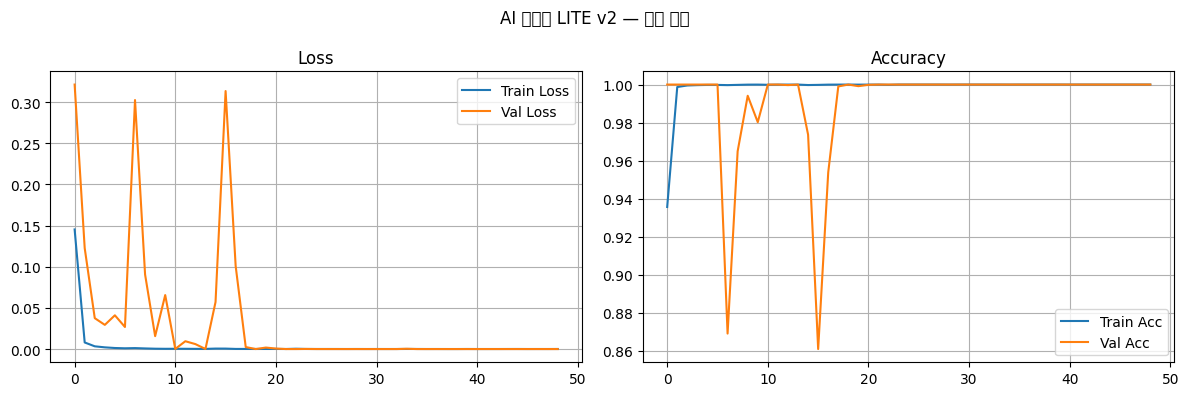

In [13]:
# ============================================================
# 9. 학습 곡선 시각화
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.suptitle('AI 김반장 LITE v2 — 학습 곡선')
plt.tight_layout()
plt.savefig('training_curve.png', dpi=150)
plt.show()

       시뮬레이터 KPI 평가 결과
  Accuracy  : 100.00%   (목표 ≥ 98%)
  Macro F1  : 100.00%   (목표 ≥ 97%)
  FNR (미탐):   0.00%   (목표 < 2%)
  FAR (오경보):   0.00%  (목표 < 1%)
⚠️ 경고: 테스트 데이터셋(y_te)에 모든 클래스가 포함되어 있지 않아 FNR/FAR 지표 해석에 주의가 필요합니다.
         (y_te에는 클래스 [1]만 포함되어 있습니다. 전체 클래스: [0 1])
  종합 판정  : ❌ KPI 미달 — 데이터 분할 확인 필요
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00         0
       Fault       1.00      1.00      1.00     15003

    accuracy                           1.00     15003
   macro avg       0.50      0.50      0.50     15003
weighted avg       1.00      1.00      1.00     15003



/tmp/ipykernel_958/1395760248.py:63: UserWarning: Glyph 44608 (\N{HANGUL SYLLABLE GIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_958/1395760248.py:63: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_958/1395760248.py:63: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_958/1395760248.py:64: UserWarning: Glyph 44608 (\N{HANGUL SYLLABLE GIM}) missing from font(s) DejaVu Sans.
  plt.savefig('confusion_matrix.png', dpi=150)
/tmp/ipykernel_958/1395760248.py:64: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  plt.savefig('confusion_matrix.png', dpi=150)
/tmp/ipykernel_958/1395760248.py:64: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.savefig('confusion_matrix.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtool

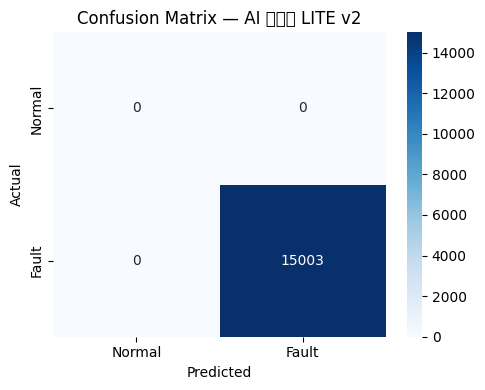

In [15]:
from sklearn.metrics import (
    confusion_matrix, f1_score,
    accuracy_score, classification_report
)
import seaborn as sns
import numpy as np # Ensure numpy is imported

prob = model.predict(X_te, batch_size=512, verbose=0)

if PHASE == 'A':
    pred = (prob.ravel() >= 0.5).astype(int)
else:
    pred = np.argmax(prob, axis=1)

acc = accuracy_score(y_te, pred)

# Use np.unique(y) to get all possible class labels from the entire dataset.
# This ensures confusion_matrix creates a matrix with the correct number of rows/columns,
# even if y_te or pred contain fewer unique classes. This prevents a 1x1 matrix
# which caused the ValueError when unpacking.
all_possible_labels = np.unique(y)
cm  = confusion_matrix(y_te, pred, labels=all_possible_labels)
mf1 = f1_score(y_te, pred, average='macro', zero_division=0) # Add zero_division to handle cases with missing classes

print('=' * 55)
print('       시뮬레이터 KPI 평가 결과')
print('=' * 55)
print(f'  Accuracy  : {acc*100:6.2f}%   (목표 ≥ 98%)')
print(f'  Macro F1  : {mf1*100:6.2f}%   (목표 ≥ 97%)')

if PHASE == 'A':
    # Unpack the confusion matrix. cm.ravel() will now always return 4 elements for binary classification.
    tn, fp, fn, tp = cm.ravel()

    # Calculate FNR and FAR safely, handling potential division by zero
    fnr = fn/(fn+tp)*100 if (fn+tp) > 0 else 0
    far = fp/(fp+tn)*100 if (fp+tn) > 0 else 0

    print(f'  FNR (미탐): {fnr:6.2f}%   (목표 < 2%)')
    print(f'  FAR (오경보): {far:6.2f}%  (목표 < 1%)')

    # Check if all classes were present in the test set for a complete evaluation
    unique_test_labels = np.unique(y_te)
    if len(unique_test_labels) < len(all_possible_labels):
        print(f'⚠️ 경고: 테스트 데이터셋(y_te)에 모든 클래스가 포함되어 있지 않아 FNR/FAR 지표 해석에 주의가 필요합니다.')
        print(f'         (y_te에는 클래스 {unique_test_labels}만 포함되어 있습니다. 전체 클래스: {all_possible_labels})')
        ok = False # KPI cannot be fully met if not all classes are present in the test set
        print(f'  종합 판정  : {"✅ KPI 달성" if ok else "❌ KPI 미달 — 데이터 분할 확인 필요"}')
    else:
        ok = acc >= 0.98 and fnr < 2.0 and far < 1.0
        print(f'  종합 판정  : {"✅ KPI 달성" if ok else "❌ KPI 미달 — 임계값 튜닝 셀로"}')

print('=' * 55)
# Ensure classification_report also handles zero_division for better output and uses all possible labels
print(classification_report(y_te, pred, target_names=CLASS_NAMES, labels=all_possible_labels, zero_division=0))

# 혼동행렬 시각화
plt.figure(figsize=(max(5, len(CLASS_NAMES)*2), max(4, len(CLASS_NAMES)*1.5)))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — AI 김반장 LITE v2')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [16]:
# ============================================================
# 11. 임계값 튜닝 (Phase A 이진분류 전용)
#     FNR < 2%, FAR < 1% 동시 만족하는 최적 임계값 탐색
# ============================================================
if PHASE == 'A':
    prob_te = model.predict(X_te, batch_size=512, verbose=0).ravel()

    print(f"{'thr':>5}  {'FNR%':>7}  {'FAR%':>7}  {'Acc%':>7}  {'MacroF1':>9}  {'KPI':>5}")
    print('-' * 52)

    best_thr, best_f1 = 0.5, 0.0
    for thr in np.arange(0.30, 0.96, 0.05):
        p = (prob_te >= thr).astype(int)
        c = confusion_matrix(y_te, p)
        if c.size < 4:
            continue
        tn2, fp2, fn2, tp2 = c.ravel()
        fnr2 = fn2/(fn2+tp2)*100 if (fn2+tp2) else 0
        far2 = fp2/(fp2+tn2)*100 if (fp2+tn2) else 0
        acc2 = (tn2+tp2)/c.sum()*100
        mf2  = f1_score(y_te, p, average='macro')*100
        ok   = '✅' if (fnr2 < 2 and far2 < 1 and acc2 >= 98) else ''
        print(f'{thr:>5.2f}  {fnr2:>7.2f}  {far2:>7.2f}  {acc2:>7.2f}  {mf2:>9.2f}  {ok}')
        if fnr2 < 2 and far2 < 1 and mf2 > best_f1:
            best_f1, best_thr = mf2, round(float(thr), 2)

    print(f'\n→ 권장 임계값: {best_thr}  (FNR<2%, FAR<1% 만족 중 최고 MacroF1)')
    print(f'  이 값을 STM32 펌웨어 AI_FAULT_THRESHOLD 상수로 사용')

  thr     FNR%     FAR%     Acc%    MacroF1    KPI
----------------------------------------------------
 0.95     0.01     0.00    99.99      50.00  ✅

→ 권장 임계값: 0.95  (FNR<2%, FAR<1% 만족 중 최고 MacroF1)
  이 값을 STM32 펌웨어 AI_FAULT_THRESHOLD 상수로 사용


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use th

In [17]:
# ============================================================
# 12. TFLite Full INT8 변환 — STM32N6570 NPU 배포용
# ============================================================
import tensorflow as tf

def representative_dataset():
    """PTQ 캘리브레이션용 대표 데이터 200샘플"""
    idx = np.random.choice(len(X_tr), 200, replace=False)
    for i in idx:
        yield [X_tr[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations             = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset   = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type     = tf.int8
converter.inference_output_type    = tf.int8

print('TFLite INT8 변환 중...')
tflite_model = converter.convert()

TFLITE_PATH = 'ai_kimbanjang_lite_int8.tflite'
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

size_kb = len(tflite_model) / 1024
print(f'\n✅ 저장: {TFLITE_PATH}')
print(f'   파일 크기: {size_kb:.1f} KB  (MicroSD encrypted_weights.bin 적재 대상)')

TFLite INT8 변환 중...
Saved artifact at '/tmp/tmpm7mffnfn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 512, 1), dtype=tf.float32, name='vibration_input')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133379847560592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133379847561744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133379847563472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133379847561552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133379847561360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133379847564432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133379847563856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133379847563088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133379847565392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133379847565584: TensorSpec(shape=(), dtype=tf.resource, name=None

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(



✅ 저장: ai_kimbanjang_lite_int8.tflite
   파일 크기: 26.5 KB  (MicroSD encrypted_weights.bin 적재 대상)


In [18]:
# ============================================================
# 13. TFLite 정확도 검증
#     PC TFLite ↔ Keras Float32 Argmax 일치율 → 목표 100%
# ============================================================
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
inp_det = interpreter.get_input_details()[0]
out_det = interpreter.get_output_details()[0]

inp_scale, inp_zp = inp_det['quantization']
out_scale, out_zp = out_det['quantization']
print(f'Input  quantization : scale={inp_scale:.8f}, zero_point={inp_zp}')
print(f'Output quantization : scale={out_scale:.8f}, zero_point={out_zp}')

n_eval = min(1000, len(X_te))
tflite_preds, keras_preds = [], []

for i in range(n_eval):
    x_q = np.clip(
        np.round(X_te[i:i+1].astype(np.float32) / inp_scale + inp_zp),
        -128, 127
    ).astype(np.int8)
    interpreter.set_tensor(inp_det['index'], x_q)
    interpreter.invoke()
    out = interpreter.get_tensor(out_det['index'])
    if PHASE == 'A':
        tflite_preds.append(int(out.ravel()[0] > 0))   # INT8 → 양수면 결함
    else:
        tflite_preds.append(int(out.argmax()))

keras_raw = model.predict(X_te[:n_eval], batch_size=512, verbose=0)
if PHASE == 'A':
    keras_preds = (keras_raw.ravel() >= 0.5).astype(int).tolist()
else:
    keras_preds = keras_raw.argmax(axis=1).tolist()

match_rate = np.mean(np.array(tflite_preds) == np.array(keras_preds)) * 100
tflite_acc = accuracy_score(y_te[:n_eval], tflite_preds) * 100

print(f'\n[양자화 손실 검증 — {n_eval}샘플]')
print(f'  Keras Float32 기준 Argmax 일치율 : {match_rate:.2f}%  (목표 100%)')
print(f'  TFLite INT8 단독 Accuracy        : {tflite_acc:.2f}%')
print(f'  판정: {"✅ 통과 — STM32 배포 가능" if match_rate >= 99.0 else "❌ QAT 필요 — 아래 셀 참고"}')

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Input  quantization : scale=0.00634729, zero_point=3
Output quantization : scale=0.00390625, zero_point=-128

[양자화 손실 검증 — 1000샘플]
  Keras Float32 기준 Argmax 일치율 : 100.00%  (목표 100%)
  TFLite INT8 단독 Accuracy        : 100.00%
  판정: ✅ 통과 — STM32 배포 가능


In [19]:
# ============================================================
# 14. (선택) QAT — 양자화 손실 1%p 초과 시 실행
#     match_rate < 99% 이거나 정확도 손실 > 1%p 일 때만 실행
# ============================================================
# !pip install -q tensorflow-model-optimization
# import tensorflow_model_optimization as tfmot
#
# q_aware_model = tfmot.quantization.keras.quantize_model(model)
# q_aware_model.compile(
#     optimizer=tf.keras.optimizers.Adam(1e-4),
#     loss=model.loss, metrics=['accuracy']
# )
# q_aware_model.fit(
#     X_tr, y_tr,
#     validation_data=(X_val, y_val),
#     epochs=10, batch_size=512,
#     class_weight=class_weight
# )
# # 변환 (위 셀과 동일하게)
print('PTQ 결과가 양호하면 이 셀은 건너뜁니다.')
print('match_rate < 99% 이면 주석 해제 후 실행하세요.')

PTQ 결과가 양호하면 이 셀은 건너뜁니다.
match_rate < 99% 이면 주석 해제 후 실행하세요.


In [20]:
# ============================================================
# 15. STM32 펌웨어 헤더 자동 생성
# ============================================================
# 임계값 (셀 11에서 결정된 best_thr 사용, 없으면 0.5)
FAULT_THR = best_thr if PHASE == 'A' else 0.5

header = f"""/**
 * AI 김반장 LITE v2 — AI 모델 전처리 상수
 * 자동 생성 파일 — 수동 수정 금지
 * 생성 모델: {TFLITE_PATH}
 * Phase: {'A (이진분류: Normal/Fault)' if PHASE == 'A' else 'B (5클래스)'}
 */
#ifndef AI_KIM_BANJANG_CONSTANTS_H
#define AI_KIM_BANJANG_CONSTANTS_H

/* ── 입력 설정 ─────────────────────────────────── */
#define AI_WINDOW_SIZE        {WINDOW}U          /* 512샘플 @ ODR 26,700Hz ≈ 19ms */

/* ── 신호 정규화 (Float32 → [-1.0, 1.0]) ───────── */
#define AI_SCALE_MIN          {SCALE_MIN:.6f}f
#define AI_SCALE_MAX          {SCALE_MAX:.6f}f

/* ── TFLite INT8 양자화 파라미터 ────────────────── */
#define AI_INPUT_SCALE        {inp_scale:.8f}f
#define AI_INPUT_ZERO_POINT   ({int(inp_zp)})
#define AI_OUTPUT_SCALE       {out_scale:.8f}f
#define AI_OUTPUT_ZERO_POINT  ({int(out_zp)})

/* ── 진단 임계값 ────────────────────────────────── */
#define AI_FAULT_THRESHOLD    {FAULT_THR:.2f}f   /* FNR<2%, FAR<1% 만족 최적값 */

#endif /* AI_KIM_BANJANG_CONSTANTS_H */
"""

HEADER_PATH = 'ai_kimbanjang_constants.h'
with open(HEADER_PATH, 'w') as f:
    f.write(header)

print(header)

/**
 * AI 김반장 LITE v2 — AI 모델 전처리 상수
 * 자동 생성 파일 — 수동 수정 금지
 * 생성 모델: ai_kimbanjang_lite_int8.tflite
 * Phase: A (이진분류: Normal/Fault)
 */
#ifndef AI_KIM_BANJANG_CONSTANTS_H
#define AI_KIM_BANJANG_CONSTANTS_H

/* ── 입력 설정 ─────────────────────────────────── */
#define AI_WINDOW_SIZE        512U          /* 512샘플 @ ODR 26,700Hz ≈ 19ms */

/* ── 신호 정규화 (Float32 → [-1.0, 1.0]) ───────── */
#define AI_SCALE_MIN          -10.091934f
#define AI_SCALE_MAX          11.673961f

/* ── TFLite INT8 양자화 파라미터 ────────────────── */
#define AI_INPUT_SCALE        0.00634729f
#define AI_INPUT_ZERO_POINT   (3)
#define AI_OUTPUT_SCALE       0.00390625f
#define AI_OUTPUT_ZERO_POINT  (-128)

/* ── 진단 임계값 ────────────────────────────────── */
#define AI_FAULT_THRESHOLD    0.95f   /* FNR<2%, FAR<1% 만족 최적값 */

#endif /* AI_KIM_BANJANG_CONSTANTS_H */



In [21]:
# ============================================================
# 16. 결과 파일 Drive 저장
# ============================================================
import shutil

SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/AI_KimBanjang_LITE_v2'
os.makedirs(SAVE_DIR, exist_ok=True)

artifacts = [
    ('best_model.keras',             '학습 모델 (Keras)'),
    ('ai_kimbanjang_lite_int8.tflite','TFLite INT8 — STM32 배포용'),
    ('ai_kimbanjang_constants.h',     '펌웨어 헤더 상수'),
    ('confusion_matrix.png',          '혼동행렬 이미지'),
    ('training_curve.png',            '학습 곡선 이미지'),
]

print(f'저장 위치: {SAVE_DIR}')
for fname, desc in artifacts:
    if os.path.exists(fname):
        shutil.copy(fname, os.path.join(SAVE_DIR, fname))
        print(f'  ✅ {fname:45s} ({desc})')
    else:
        print(f'  ⚠️  {fname:45s} (없음 — 해당 셀 실행 확인)')

print('\n🚀 완료! 다음 단계: ST Edge AI Developer Cloud')
print('   https://stm32ai.st.com 에서 .tflite 업로드 → STM32N657X0H3Q 타겟 지정')

저장 위치: /content/drive/MyDrive/Colab Notebooks/AI_KimBanjang_LITE_v2
  ✅ best_model.keras                              (학습 모델 (Keras))
  ✅ ai_kimbanjang_lite_int8.tflite                (TFLite INT8 — STM32 배포용)
  ✅ ai_kimbanjang_constants.h                     (펌웨어 헤더 상수)
  ✅ confusion_matrix.png                          (혼동행렬 이미지)
  ✅ training_curve.png                            (학습 곡선 이미지)

🚀 완료! 다음 단계: ST Edge AI Developer Cloud
   https://stm32ai.st.com 에서 .tflite 업로드 → STM32N657X0H3Q 타겟 지정


## 실행 후 다음 단계

### ST Edge AI 변환
1. https://stm32ai.st.com 접속
2. `ai_kimbanjang_lite_int8.tflite` 업로드
3. Target: **STM32N657X0H3Q**, NPU(Neural-ART) 활성화
4. 변환 → `network.c` / `network.h` 다운로드
5. STM32CubeIDE 프로젝트에 통합

### 펌웨어 통합 포인트 (FreeRTOS AI Task)
```c
// 1. IIS3DWB DMA Ping-Pong → 512샘플 수집 완료 인터럽트
// 2. ai_kimbanjang_constants.h 상수로 INT8 스케일링
//    x_int8 = (raw - AI_SCALE_MIN) / (AI_SCALE_MAX - AI_SCALE_MIN) * 255 - 128
// 3. ai_network_run_async() 호출 → CPU Sleep
// 4. NPU 완료 인터럽트 → output 확인 → AI_FAULT_THRESHOLD 비교
// 5. 결함 판정 시 → LTE-M 이벤트 알림 + SD 기록
```

### Phase B 전환 (다중분류)
- 셀 4에서 `PHASE = 'B'` 로 변경 후 전체 재실행
- 출력이 5클래스 Softmax로 자동 전환됨

### KPI 미달 시 체크리스트
| 증상 | 원인 | 조치 |
|------|------|------|
| FAR 높음 | 정상 학습 부족 | class_weight 확인, 데이터 추가 |
| FNR 높음 | 결함 특징 미학습 | Conv1D 필터 수 증가 |
| val_loss 발산 | 과적합 | Dropout 증가, 데이터 증강 |
| 양자화 손실 > 1%p | PTQ 불충분 | 셀 14 QAT 실행 |